# Telco Customer Churn Analysis

## 1. Data loading, Initial Exploration, Data Cleaning, Exploratory Analysis

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

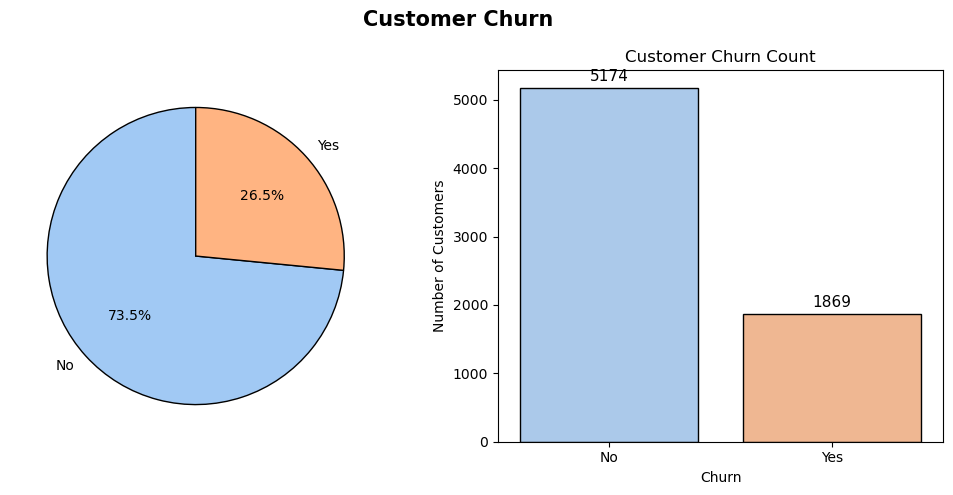

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# let's count the number of customers in each churn category

churn_stats = df["Churn"].value_counts()

# Create side-by-side plots for churn distribution(pie and bars)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

colors = sns.color_palette("pastel", df["Churn"].nunique())

# Display churn distribution as a pie chart

ax[0].pie(
    churn_stats,
    labels=["No", "Yes"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

# Display churn distribution as a count plot

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette="pastel",
    edgecolor="black",
    legend=False,
    ax=ax[1] 
)

# Adding the numerical values of the bars

for container in ax[1].containers:
    ax[1].bar_label(container, fontsize=11, padding=3)

# Customizing the count plot
ax[1].set_title("Customer Churn Count")
ax[1].set_xlabel("Churn")
ax[1].set_ylabel("Number of Customers")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["No", "Yes"])

fig.suptitle("Customer Churn", fontsize=15, fontweight="bold")



plt.tight_layout();

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# counting missing values
missing_val_count_by_column = df.isnull().sum()

print(missing_val_count_by_column[missing_val_count_by_column > 0])

Series([], dtype: int64)


In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["TotalCharges"].head()#something is wrong with this column, it should be numerical but dtype is object

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [8]:
df["TotalCharges"].describe()

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object

In [9]:
(df["TotalCharges"] == " ").sum() # we checked above there is no nan maybe it is " "

np.int64(11)

In [10]:
#let's check if there are similar problems in other columns (it seems only in TotalCharges)
df.apply(lambda col: col.astype(str).str.strip().eq("").sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df["MultipleLines"].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [12]:
df["Contract"].value_counts() 

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [13]:
# Churn ratio of one years and two years are lower
pd.crosstab(
    df["Contract"],
    df["Churn"],
    margins=True
)

Churn,No,Yes,All
Contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


In [14]:
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
)#as expected gender has no big impact

Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


In [15]:
# writing the same as ratios
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [16]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [17]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


In [18]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


In [19]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [20]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

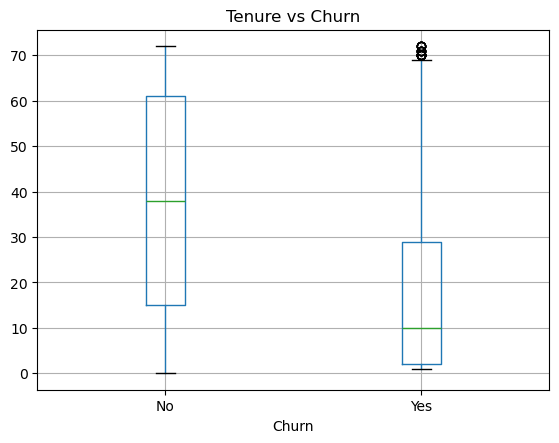

In [21]:
import matplotlib.pyplot as plt

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure vs Churn")
plt.suptitle("")
plt.show()

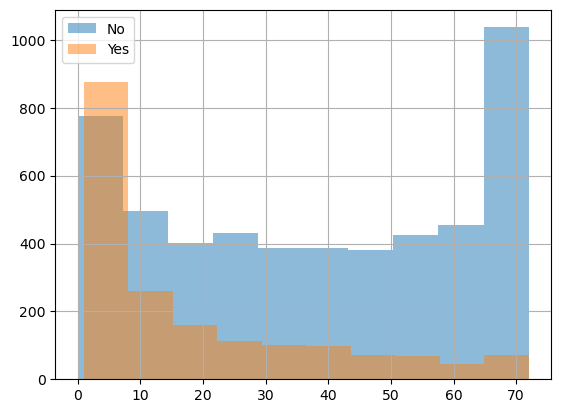

In [22]:
df.groupby("Churn")["tenure"].hist(alpha=0.5, legend=True)
plt.show()

##### Ones with high tenure is less likely to churn

In [23]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [24]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [25]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651


In [26]:
pd.crosstab(
    df["PaymentMethod"],
    df["Contract"]
)#these two guys seem correlated 

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),589,391,564
Credit card (automatic),543,398,581
Electronic check,1850,347,168
Mailed check,893,337,382


In [27]:
#Now let's solve the problem with TotalCharges
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [28]:
#let's find them
df[df["TotalCharges"]==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [29]:
df[df["TotalCharges"] == " "][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [30]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)# make it numeric, if cannot put NaN(this is what errors="coerce" does)

#we saw that when Total Charges " " tenure=0 meaning new customers so we can
#make TotalCharges=0 for them
df["TotalCharges"] = df["TotalCharges"].fillna(0) #replace NaNs with 0s

In [31]:
df.apply(lambda col: col.astype(str).str.strip().eq("").sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [32]:
df[["tenure",
    "MonthlyCharges",
    "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


In [33]:
(df["TotalCharges"] - df["MonthlyCharges"] * df["tenure"]).describe()#not equal

count    7043.000000
mean        0.152953
std        67.202778
min      -370.850000
25%       -28.600000
50%         0.000000
75%        28.500000
max       373.250000
dtype: float64

## 2. SQL Analysis

### SQL, Try to do similar stuff with SQL

In [34]:
import sqlite3

conn = sqlite3.connect("churn.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

7043

In [35]:
pd.read_sql(
    "SELECT COUNT(*) as NumOfRows FROM customers",
    conn
)

,NumOfRows
0,7043


In [36]:
query = """
SELECT
    Contract,
    COUNT(*) AS customer_count
FROM customers
GROUP BY Contract
"""

pd.read_sql(query, conn)

,Contract,customer_count
0,Month-to-month,3875
1,One year,1473
2,Two year,1695


In [37]:
#in sql turn yes,no churns to 1,0
query = """
SELECT
    Contract,
    AVG(
        CASE
            WHEN Churn='Yes' THEN 1
            ELSE 0
        END
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC
"""

pd.read_sql(query, conn)

,Contract,churn_rate
0,Month-to-month,0.427097
1,One year,0.112695
2,Two year,0.028319


In [38]:
query = """
SELECT
    PaymentMethod,
    AVG(
        CASE
            WHEN Churn='Yes' THEN 1
            ELSE 0
        END
    ) AS churn_rate,
    COUNT(*) AS n
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC
"""

pd.read_sql(query, conn)

,PaymentMethod,churn_rate,n
0,Electronic check,0.452854,2365
1,Mailed check,0.191067,1612
2,Bank transfer (automatic),0.167098,1544
3,Credit card (automatic),0.152431,1522


In [39]:
query = """
SELECT
    Churn,
    AVG(tenure) AS avg_tenure,
    MIN(tenure) AS min_tenure,
    MAX(tenure) AS max_tenure
FROM customers
GROUP BY Churn
"""

pd.read_sql(query, conn)

,Churn,avg_tenure,min_tenure,max_tenure
0,No,37.569965,0,72
1,Yes,17.979133,1,72


In [40]:
query = """
SELECT
    Contract,
    InternetService,
    AVG(
        CASE
            WHEN Churn='Yes' THEN 1
            ELSE 0
        END
    ) AS churn_rate,
    COUNT(*) AS n
FROM customers
GROUP BY
    Contract,
    InternetService
ORDER BY churn_rate DESC 
"""
pd.read_sql(query, conn)

,Contract,InternetService,churn_rate,n
0,Month-to-month,Fiber optic,0.546053,2128
1,Month-to-month,DSL,0.322159,1223
2,One year,Fiber optic,0.192950,539
3,Month-to-month,No,0.188931,524
4,One year,DSL,0.092982,570
5,Two year,Fiber optic,0.072261,429
6,One year,No,0.024725,364
7,Two year,DSL,0.019108,628
8,Two year,No,0.007837,638


### SQL test is over

## 3. Logistic Regression

In [41]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})
# drop meaningless feature and target to create X
X = df.drop(columns=["Churn", "customerID"])
# choosing Churn as the target
y = df["Churn"]

print(X.shape)

(7043, 19)


In [42]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: Churn
Non-Null Count  Dtype
--------------  -----
7043 non-null   int64
dtypes: int64(1)
memory usage: 55.2 KB


In [43]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [45]:
categorical_features = [cname for cname in X.columns if
                    X[cname].dtype == "object"]

# Select numerical columns
numerical_features = [cname for cname in X.columns if 
                X[cname].dtype in ['int64', 'float64']]

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

In [47]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##  4. Feature Importance

### 4.1 Logistic Regression Coefficients

#### Since we use "drop=first" the coefficients in categorical variables are interpreted based on the reference category.Therefore:"Contract_Two year = -1.31" This means : While other variables remain constant, the log-odds of Two year customers are lower than those in the reference Contract category.

In [48]:
# Get feature names after preprocessing
import numpy as np
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Absolute coefficient = magnitude of effect
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort by absolute coefficient
coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df["effect"] = np.where(
    coef_df["coefficient"] > 0,
    "Increases churn",
    "Decreases churn"
)

coef_df.head(20)

,feature,coefficient,abs_coefficient,effect
1,num__tenure,-1.466851,1.466851,Decreases churn
25,cat__Contract_Two year,-1.308975,1.308975,Decreases churn
24,cat__Contract_One year,-0.739300,0.739300,Decreases churn
7,cat__PhoneService_Yes,-0.710495,0.710495,Decreases churn
3,num__TotalCharges,0.688176,0.688176,Increases churn
13,cat__OnlineSecurity_Yes,-0.450024,0.450024,Decreases churn
19,cat__TechSupport_Yes,-0.418788,0.418788,Decreases churn
2,num__MonthlyCharges,0.405348,0.405348,Increases churn
26,cat__PaperlessBilling_Yes,0.365606,0.365606,Increases churn
10,cat__InternetService_Fiber optic,0.364670,0.364670,Increases churn


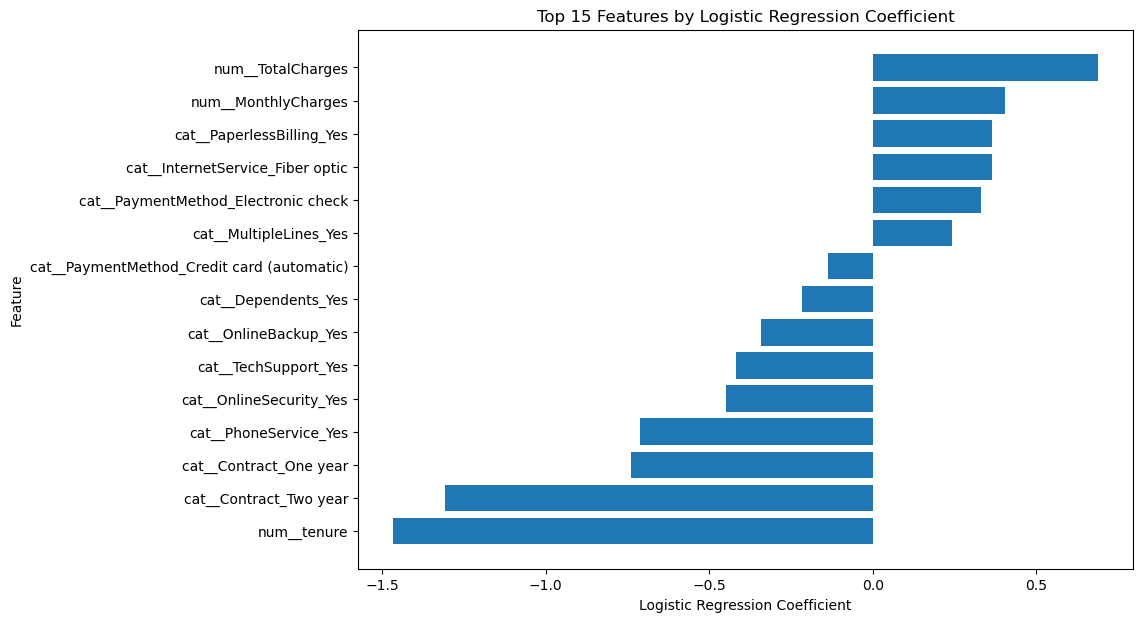

In [49]:

top = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["coefficient"])

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features by Logistic Regression Coefficient")

plt.show()

### 4.2 Permutation Importance
#### This method shuffles the content of one features and measure the change. in this case we check how roc_auc score will change

In [50]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10, # shuffling 10 times, hence the std in below table
    random_state=0
)

In [51]:
# Let's convert the result to a DataFrame.

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    "importance",
    ascending=False
)

perm_df

,feature,importance,std
4,tenure,0.174772,0.011711
18,TotalCharges,0.032535,0.005754
14,Contract,0.026716,0.006575
17,MonthlyCharges,0.019725,0.004016
5,PhoneService,0.006532,0.001637
7,InternetService,0.005696,0.001519
8,OnlineSecurity,0.005610,0.001576
11,TechSupport,0.004994,0.001056
15,PaperlessBilling,0.004575,0.001394
16,PaymentMethod,0.003272,0.001190


#### Let's also visualize it.

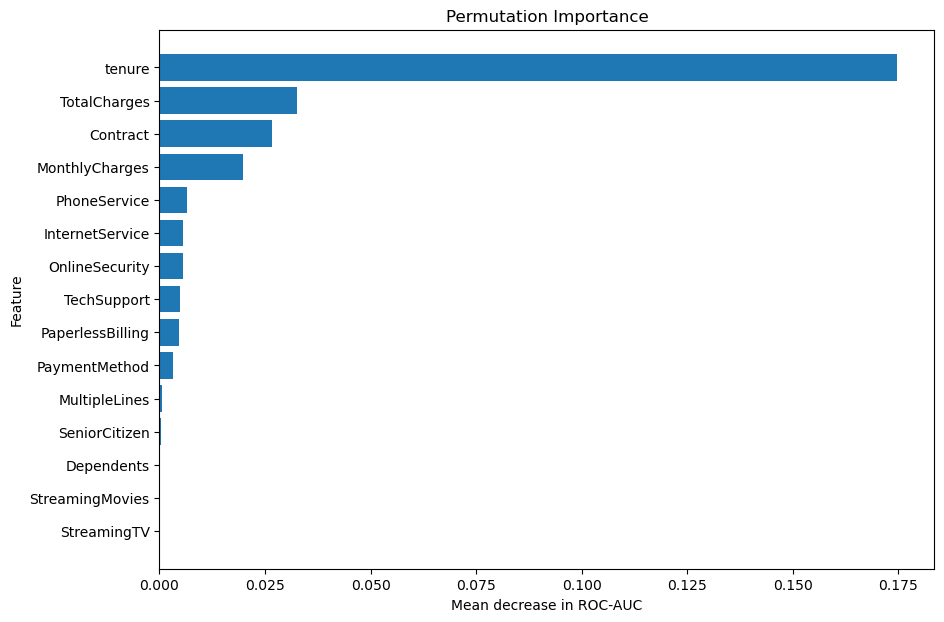

In [52]:
top_feat = perm_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_feat["feature"],
    top_feat["importance"]
)

plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Importance")

plt.show()

##### Tenure seems to be the strongest predictor of churn in this model. Longer-tenured customers are substantially less likely to churn. Similar to what we see in EDA

### 4.3 Mutual Information(MI)

##### How much information/dependency exists between churn and feature, independent of the model?

In [53]:
from sklearn.feature_selection import mutual_info_classif

X_mi = X.copy()

for col in categorical_features:
    X_mi[col] = X_mi[col].astype("category").cat.codes

# Let's specify which features are categorical.

discrete_features = [
    col in categorical_features
    for col in X_mi.columns
]   

# Let's calculate MI.

mi_scores = mutual_info_classif(
    X_mi,
    y,
    discrete_features=discrete_features,
    random_state=0
)

mi_df = pd.DataFrame({
    "feature": X_mi.columns,
    "MI": mi_scores
})

mi_df = mi_df.sort_values(
    "MI",
    ascending=False
)

mi_df

,feature,MI
14,Contract,0.098453
4,tenure,0.067945
8,OnlineSecurity,0.064677
11,TechSupport,0.063021
7,InternetService,0.055574
9,OnlineBackup,0.046792
17,MonthlyCharges,0.045535
18,TotalCharges,0.045046
16,PaymentMethod,0.044519
10,DeviceProtection,0.043917


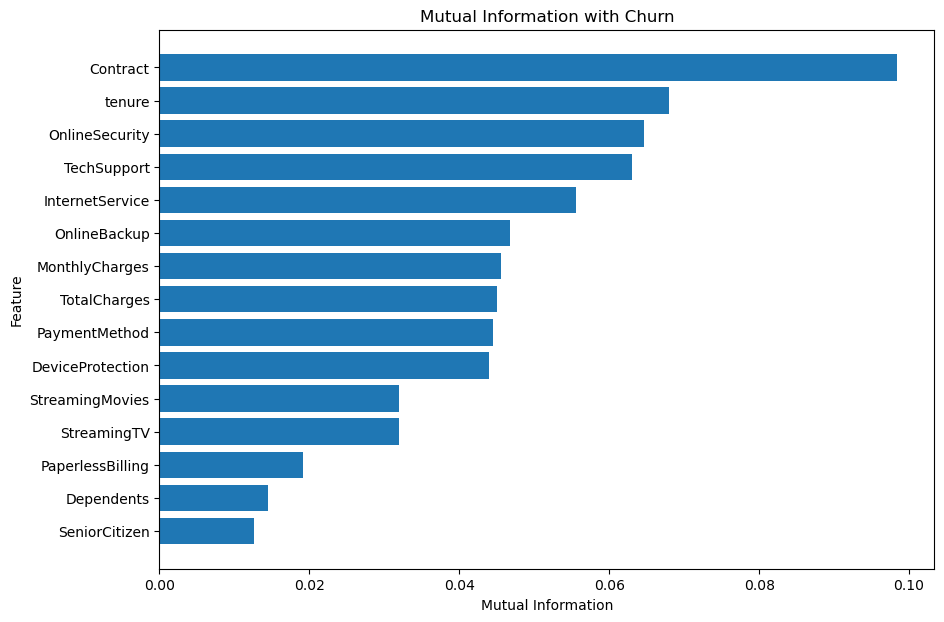

In [54]:
top_mi = mi_df.head(15).sort_values("MI")

plt.figure(figsize=(10, 7))

plt.barh(
    top_mi["feature"],
    top_mi["MI"]
)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information with Churn")

plt.show()

#### Feature importance was assessed using three complementary approaches: logistic regression coefficients, permutation importance, and mutual information. While the exact ranking differed across methods, tenure, contract type, service-related variables, and billing/charge-related variables consistently emerged as important predictors. Gender consistently showed negligible predictive value.

## 5. Model Evaluation

### Accuracy

In [55]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7970191625266146


### Confusion Matrix

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[930 111]
 [175 193]]


### Recall, Precision and F1-Score

##### The true positive rate (TPR), or the proportion of all actual positives that were classified correctly as positives, is also known as recall.
##### The false positive rate (FPR) is the proportion of all actual negatives that were classified incorrectly as positives, also known as the probability of false alarm.
##### Precision is the proportion of all the model's positive classifications that are actually positive.

In [57]:
# Recall(how many of the positives we caught) and precision(how right are we) and F1 score
precision = float(round(cm[1,1]/(cm[0,1]+cm[1,1]),3))
recall = float(round(cm[1,1]/(cm[1,0]+cm[1,1]),3))
f1_score = round(2/(1/recall+1/precision),3)

print(f"Precision : {precision}")
print(f"Recall : {recall}")
print(f"F1-score : {f1_score}")

Precision : 0.635
Recall : 0.524
F1-score : 0.574


In [58]:
# withlibrary asistance
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


Precision: 0.6348684210526315
Recall: 0.5244565217391305
F1: 0.5744047619047619


## 6. ROC-AUC

In [59]:
y_prob = model.predict_proba(X_test)
print(y_prob[:5]) # first column is P(churn=0), second one is P(churn=1)

[[0.84628101 0.15371899]
 [0.88915267 0.11084733]
 [0.55141489 0.44858511]
 [0.93493695 0.06506305]
 [0.81061675 0.18938325]]


In [60]:
from sklearn.metrics import roc_auc_score
y_prob = y_prob[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC : ", auc)# score is not bad, model seems good at ordering(separating)

ROC-AUC :  0.8270136365534813


#### let's draw the ROC curve to see

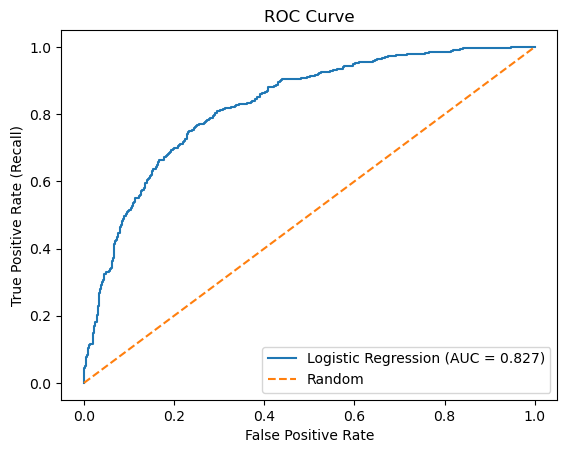

In [61]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 7. Threshold Analysis

In [62]:
# codes automatically uses 0.5 as threshold, Let's try different ones and see
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    
    y_pred_t = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.2 | Precision: 0.455 | Recall: 0.832 | F1: 0.588
Threshold: 0.3 | Precision: 0.522 | Recall: 0.753 | F1: 0.616
Threshold: 0.4 | Precision: 0.583 | Recall: 0.658 | F1: 0.618
Threshold: 0.5 | Precision: 0.635 | Recall: 0.524 | F1: 0.574
Threshold: 0.6 | Precision: 0.668 | Recall: 0.361 | F1: 0.469
Threshold: 0.7 | Precision: 0.705 | Recall: 0.182 | F1: 0.289
Threshold: 0.8 | Precision: 0.917 | Recall: 0.030 | F1: 0.058


##### if we want to max the F1 then 0.4 seems best. but in the end what is best is decided by 
##### what you want from the model. e.g. if you don't care about false alarms then go ahead and max recall

## 8. Business Cost Analysis

### Scenario

#### Confusion Matrices for different Thresholds

In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0, 1.001, 0.001)

results = []

for threshold in thresholds:
    
    y_pred_t = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_test, 
        y_pred_t
    ).ravel()
    
    results.append({
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

results_df = pd.DataFrame(results)

results_df.head()

,threshold,TN,FP,FN,TP
0,0.000,0,1041,0,368
1,0.001,0,1041,0,368
2,0.002,18,1023,0,368
3,0.003,42,999,0,368
4,0.004,68,973,1,367


#### Let's assume that False Negatives costs us more than False Positives

In [64]:
FP_cost = 10
FN_cost = 100

In [65]:
results_df["cost"] = (
    results_df["FP"] * FP_cost
    + results_df["FN"] * FN_cost
)

results_df.sort_values("cost").head(10)

,threshold,TN,FP,FN,TP,cost
58,0.058,400,641,16,352,8010
43,0.043,346,695,11,357,8050
40,0.040,335,706,10,358,8060
57,0.057,395,646,16,352,8060
59,0.059,404,637,17,351,8070
48,0.048,364,677,13,355,8070
62,0.062,414,627,18,350,8070
42,0.042,343,698,11,357,8080
135,0.135,583,458,35,333,8080
45,0.045,353,688,12,356,8080


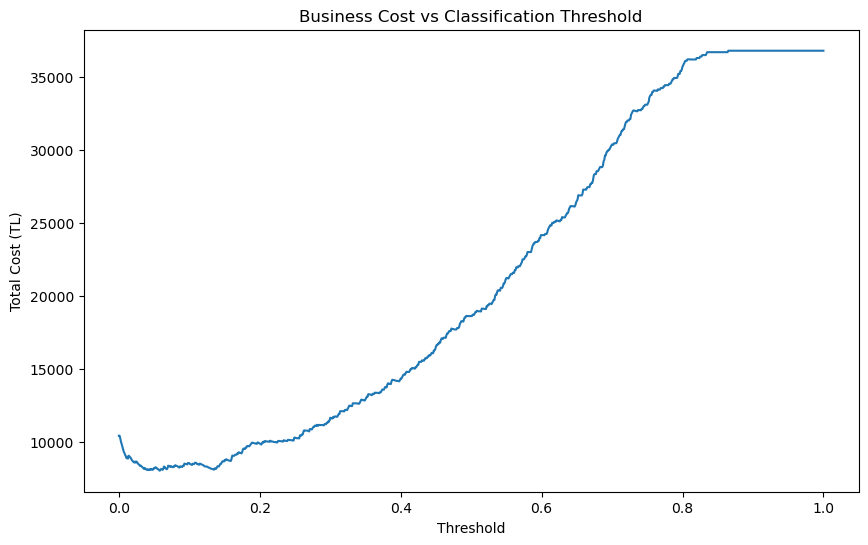

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["threshold"],
    results_df["cost"]
)

plt.xlabel("Threshold")
plt.ylabel("Total Cost (TL)")
plt.title("Business Cost vs Classification Threshold")

plt.show()

In [67]:
best_row = results_df.loc[
    results_df["cost"].idxmin()
]

print(best_row)
print(f"In this situation threshold = {float(best_row["threshold"])} seems best")
print("even if the probability of the churn is 6%, don't ignore it")

threshold       0.058
TN            400.000
FP            641.000
FN             16.000
TP            352.000
cost         8010.000
Name: 58, dtype: float64
In this situation threshold = 0.058 seems best
even if the probability of the churn is 6%, don't ignore it


#### We can make up different scenarios

In [68]:
scenarios = {
    "Normal": (10, 100),
    "Expensive Campaign": (50, 100),
    "Very Expensive Churn": (10, 500)
}

for name, (fp_cost, fn_cost) in scenarios.items():
    
    cost = (
        results_df["FP"] * fp_cost
        + results_df["FN"] * fn_cost
    )
    
    best_idx = cost.idxmin()
    
    print(
        f"{name}: "
        f"Threshold = {results_df.loc[best_idx, 'threshold']:.3f} | "
        f"Cost = {cost.loc[best_idx]:.0f} TL"
    )

Normal: Threshold = 0.058 | Cost = 8010 TL
Expensive Campaign: Threshold = 0.398 | Cost = 21100 TL
Very Expensive Churn: Threshold = 0.011 | Cost = 9260 TL


In [69]:
np.sort(y_prob)[:20]

array([0.00116592, 0.00128856, 0.00129233, 0.00130707, 0.00147611,
       0.00152636, 0.00156741, 0.00160157, 0.00169273, 0.0017163 ,
       0.00177313, 0.00179518, 0.00184341, 0.00187218, 0.00187728,
       0.00196361, 0.00196443, 0.00198165, 0.00202772, 0.0020484 ])

## 9. Retention Campaign Simulation

### Scenario with positive feedback for TP

#### 100% retention rate is assumed

In [70]:
#making up numbers
campaign_cost = 10 
churn_loss = 100  
retention_profit = 80

results_df["profit"] = (
    results_df["TP"] * (retention_profit - campaign_cost)# assumed 100% retention
    - results_df["FP"] * campaign_cost
    - results_df["FN"] * churn_loss
)

best_idx = results_df["profit"].idxmax()

results_df.loc[best_idx]

threshold        0.036
TN             319.000
FP             722.000
FN               9.000
TP             359.000
cost          8120.000
profit       17010.000
Name: 36, dtype: float64

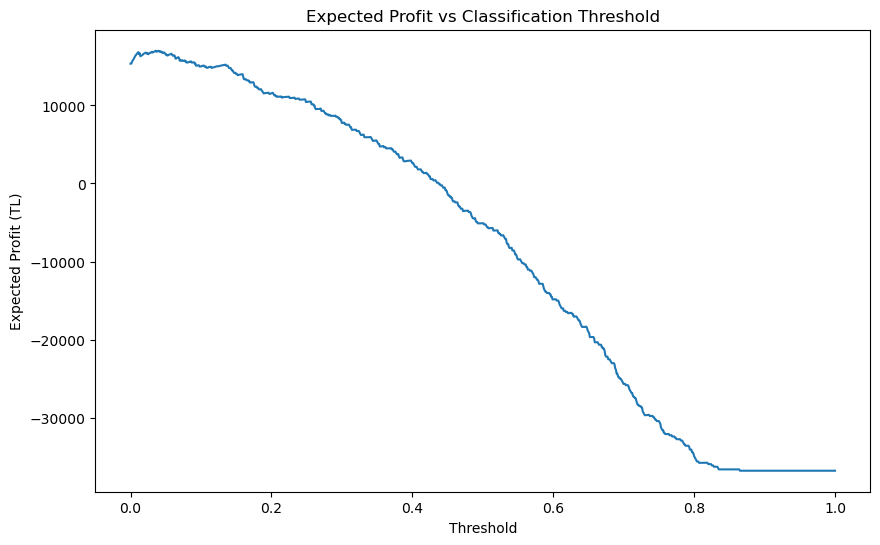

In [71]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df["threshold"],
    results_df["profit"]
)

plt.xlabel("Threshold")
plt.ylabel("Expected Profit (TL)")
plt.title("Expected Profit vs Classification Threshold")

plt.show()

#### let's do the same for different retention rates

##### create success rates and assume that these rates apply to all customers equally. this assumption means that we assume retention campaign has the same effect on everyone

In [72]:
campaign_cost = 10 
churn_loss = 100  
retention_value = 80

success_rates = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
#Assumed that these rates apply to all customers equally
results = []

for success_rate in success_rates:
    
    expected_retention_value = success_rate * retention_value
    
    profit = (
        results_df["TP"] * (expected_retention_value - campaign_cost)
        - results_df["FP"] * campaign_cost
        - results_df["FN"] * churn_loss
    )
    
    best_idx = profit.idxmax()
    
    best = results_df.loc[best_idx]
    
    results.append({
        "success_rate": success_rate,
        "threshold": best["threshold"],
        "profit": profit.loc[best_idx],
        "TP": best["TP"],
        "FP": best["FP"],
        "FN": best["FN"]
    })

profit_results = pd.DataFrame(results)

profit_results
# well it is not possible to profit if success_rate=0.1 in this case but it also seems that
# with this model and under this conditions it is not possible to profit if success_rate=<0.4

,success_rate,threshold,profit,TP,FP,FN
0,0.1,0.058,-8714.0,352.0,641.0,16.0
1,0.2,0.058,-5898.0,352.0,641.0,16.0
2,0.3,0.040,-3048.0,358.0,706.0,10.0
3,0.4,0.040,-184.0,358.0,706.0,10.0
4,0.5,0.040,2680.0,358.0,706.0,10.0
5,0.6,0.040,5544.0,358.0,706.0,10.0
6,0.7,0.040,8408.0,358.0,706.0,10.0
7,0.8,0.040,11272.0,358.0,706.0,10.0
8,0.9,0.036,14138.0,359.0,722.0,9.0
9,1.0,0.036,17010.0,359.0,722.0,9.0


##### As expected high success rate of retention campaign mean catching churning customers(TP) is more valuable. Retention success rate ↑ -> TP ↑ -> optimal threshold ↓


## 10. Conclusion

#### This analysis showed that customer churn is strongly associated with factors such as contract type, tenure, internet and support services, and payment methods. Logistic Regression provided a useful baseline model, achieving a ROC-AUC of approximately 0.83. Feature importance was examined from multiple perspectives using Logistic Regression coefficients, permutation importance, and mutual information, with tenure, contract type, service-related variables, and billing-related features consistently emerging as important predictors.

#### The analysis also showed that a classification threshold should not necessarily be fixed at 0.5. Depending on the relative costs of false positives and false negatives, a different threshold can lead to a more appropriate business decision. Extending this idea to a hypothetical retention campaign showed that the optimal threshold depends not only on the model's predictions, but also on the expected value and effectiveness of the intervention. As the success rate of the retention campaign increases, identifying potential churners becomes more valuable, leading to a lower optimal classification threshold.

#### Overall, the project demonstrates that churn modeling is not only about predicting which customers are likely to leave, but also about translating those predictions into actionable and economically meaningful decisions.